<a href="https://colab.research.google.com/github/ethansky88-oss/IS-4487/blob/main/Copy_of_assignment_05_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing**

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Business Context: Hotel Bookings

### Dataset Description:

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## **Task 1. Setup and Data Loading**

Instructions:

🔧 1.1. Import `pandas`, `seaborn`, and `matplotlib.pyplot`.

🔧 1.2. Load the dataset from this URL:
  https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv

🔧 1.3. Display some sample rows to confirm it loaded correctly.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv')

In [6]:
# 🔧 1.3. View few sample rows of the data
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## **Task 2. Stakeholder and Business Context**

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### 🔧 Please answer the following:

2.1. Who are the key stakeholders for this dataset?\
2.2. What goals might each stakeholder have?\
2.3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
2.1. The key stakeholder of this data is hotel managers, hotel cleaning staff, hotel front desk, hotel owners, travel agencies, and booking partners

2.2. Managers want to set prices and booking levels that maximize revenue. Hotel staff wants accurate see forecasts so they can staff correctly and have rooms ready. Travel agencies wants to know which guest types bring in repeat business. Owners want to compare the City and Resort hotels

2.3. This dataset can help reduce hotel room cancelations and increase revenue by analyzing what variables are causeing room cancelations.




## **Task 3. Explore Data Structure and Quality**

### Business framing:

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.



### 🔧 3.1 - 3.3. Use at least 3 techniques to examine structure and quality:
  - Summary info, summary statistics
  - Data Types
  - Missing value checks
  - Duplicate row checks
  - Detect Outliers



In [7]:
# 🔧 3.1. Get summary information and data types
print("DataFrame Info:")
df.info()

# 🔧 3.2. Get descriptive statistics for all columns
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

# 🔧 3.3. Check for missing values
print("\nMissing Values per Column:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN



Missing Values per Column:


,0
children,4
country,488
agent,16340
company,112593



Number of duplicate rows: 31994


### 🔧 Please answer the following:

3.4. What structural issues (e.g., missing values, incorrectly inferred data types, duplicates, outliers, or formatting problems) did you find?

3.5. What actions would you recommend to fix this structural issue?



### ✍️ Your Response: 🔧
3.4.We have some values missing, Children. (4 values),Country (488), Agent (16,340), and company (112,593). I also found that we have 31994 duplicate rows.
3.5.To fix the structure I should drop the company row due to the high # of missing imputs, also drop agents as well. We also need to verify or get rid of the duplicate rows.



## **Task 4. Univariate Analysis**

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### 🔧 4.1 - 4.3 Select at least 3 individual variables to explore
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)
- Use plots and summaries to describe the distribution





Distribution of 'is_canceled':


,count
is_canceled,
0,75166
1,44224


/tmp/ipykernel_1504/1323218024.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='viridis')


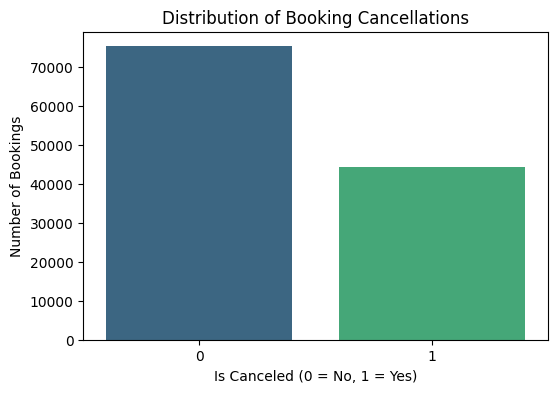


Distribution of 'hotel':


,count
hotel,
City Hotel,79330
Resort Hotel,40060


/tmp/ipykernel_1504/1323218024.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel', data=df, palette='muted')


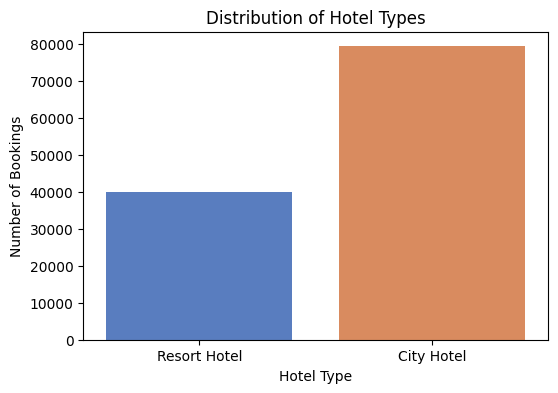


Descriptive statistics for 'lead_time':


,lead_time
count,119390.000000
mean,104.011416
std,106.863097
min,0.000000
25%,18.000000
50%,69.000000
75%,160.000000
max,737.000000


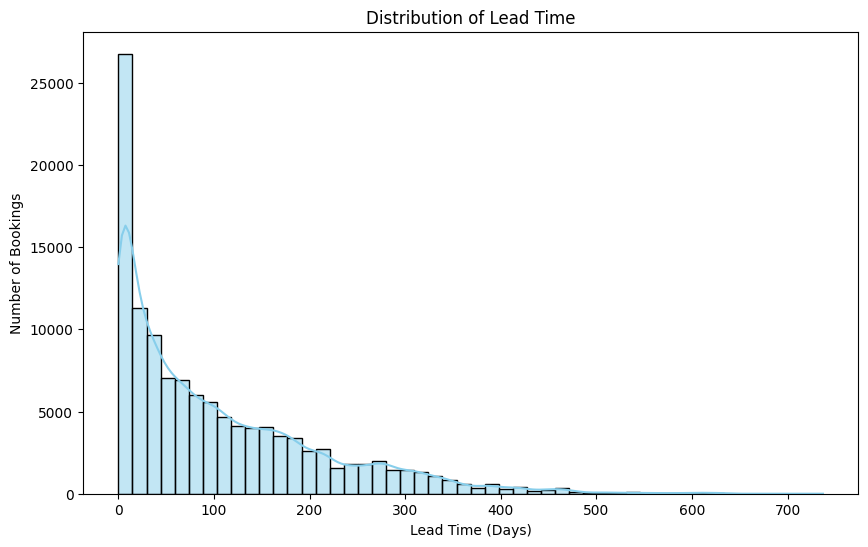

In [8]:
# 🔧 4.1. Univariate analysis for 'is_canceled'
print("Distribution of 'is_canceled':")
display(df['is_canceled'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Bookings')
plt.show()

# 🔧 4.2. Univariate analysis for 'hotel'
print("\nDistribution of 'hotel':")
display(df['hotel'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x='hotel', data=df, palette='muted')
plt.title('Distribution of Hotel Types')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

# 🔧 4.3. Univariate analysis for 'lead_time'
print("\nDescriptive statistics for 'lead_time':")
display(df['lead_time'].describe())
plt.figure(figsize=(10, 6))
sns.histplot(df['lead_time'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')
plt.show()

### 🔧 Please answer the following:

4.4. Variable 1 - What did you explore and what did you find?

4.5. Variable 2 - What did you explore and what did you find?

4.6. Variable 3 - What did you explore and what did you find?

### ✍️ Your Response: 🔧

4.4. Variable #1 displays that 37% of bookings are being cancel

4.5. Variable #2 shows that 34% of booking are for the Resort.

4.6. Variable #3 shows that lead times average around 104 days and that this chart is heavily skewed to the right. Also 50% of booking are done around 69 days.


## **Task 5. Bivariate Analysis**

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

###  🔧 5.1 - 5.2 Choose 2 relevant variable pairs to examine
- such as (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships. If the relationship or trend is not cleanly visible, then change the type of chart.
- Interpret what these relationships could mean for the hotel business






Lead Time distribution for Canceled vs. Not Canceled Bookings:


/tmp/ipykernel_1504/2674510987.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='coolwarm')


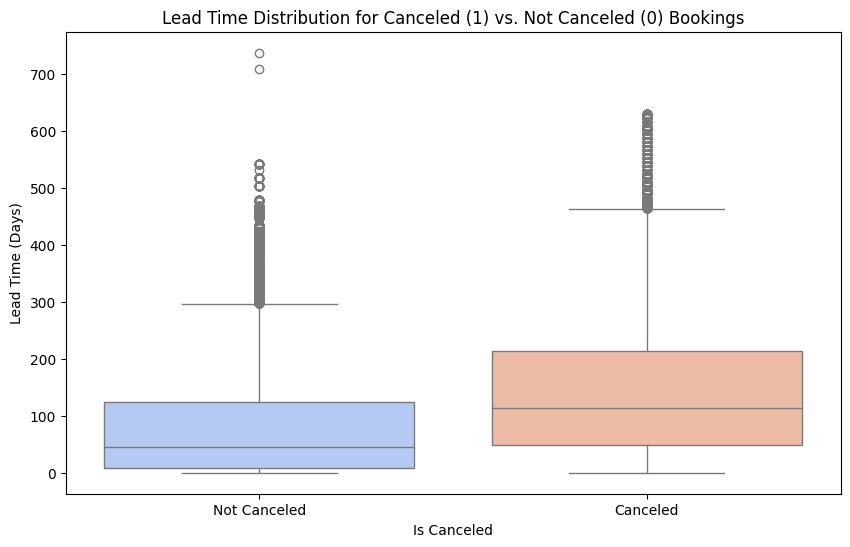


Cancellation Rate by Hotel Type:


,hotel,is_canceled,cancellation_rate
0,City Hotel,0.417270,41.726963
1,Resort Hotel,0.277634,27.763355


/tmp/ipykernel_1504/2674510987.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hotel', y='cancellation_rate', data=cancellation_by_hotel, palette='viridis')


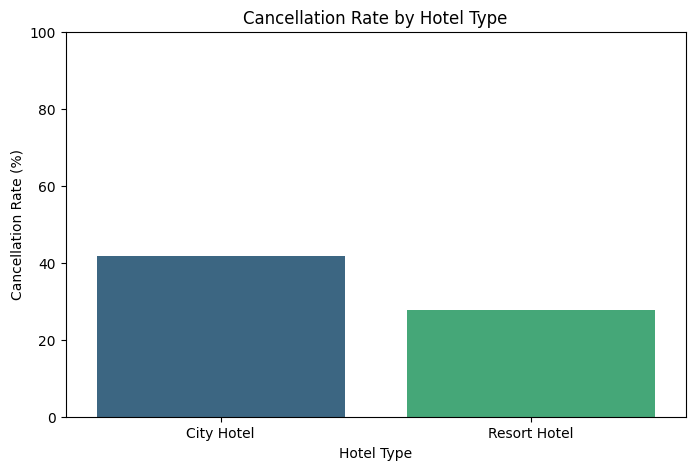

In [9]:
df = pd.read_csv('https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv')
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 5.1. Bivariate analysis: lead_time vs. is_canceled
print("\nLead Time distribution for Canceled vs. Not Canceled Bookings:")
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='coolwarm')
plt.title('Lead Time Distribution for Canceled (1) vs. Not Canceled (0) Bookings')
plt.xlabel('Is Canceled')
plt.ylabel('Lead Time (Days)')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

# 🔧 5.2. Bivariate analysis: hotel vs. is_canceled (cancellation rate by hotel type)
print("\nCancellation Rate by Hotel Type:")
cancellation_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()
cancellation_by_hotel['cancellation_rate'] = cancellation_by_hotel['is_canceled'] * 100
display(cancellation_by_hotel)

plt.figure(figsize=(8, 5))
sns.barplot(x='hotel', y='cancellation_rate', data=cancellation_by_hotel, palette='viridis')
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)
plt.show()

### 🔧 Please answer the following:

5.3. Relationship 1 - What did you analyze and what insights did you find?

5.4. Relationship 2 - What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧

5.3. Relationship 1, we see that lead time average of canceled booking is around 100 days and a range between 50 - 200 days.

5.4. Relationship 2, we see that 41% of the cancelation are at the City hotel and need to look into the relationship of lead time at this City hotel.


## **Task 6. Problem Complexity and Analytics Framing**

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

Choose one insight from your earlier analysis. Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)




### 🔧 Please answer the following:

6.1. What was your selected insight?

6.2. What kind of complexity does it involve?

6.3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧

6.1. The City Hotel has a higher cancellation rate (41%) compared to the resort (28%)

6.2. The Variety of the guest between to city and resort are very different guests, one is focused on leisure and the otherone could be a mix but primarily business.

6.3. A combination of diagnostic and prescriptive would be helpful. The diagnostic can help determine the "WHY" of the cancelations and the presciptive analysis could help us recommend what to do once we have the why and how to eliminate the why.



## **Task 7. Reflections, Final Takeaways and Recommendations**

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### 🔧 Please answer the following:

7.1. What patterns or trends stood out?

7.2. How do they connect to stakeholder goals?

7.3. What recommendation would you make based on this analysis?

7.4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

7.1. The companies overall cancelation rate is around 37% and 41% of those cancelation are from the City Hotel. We found that most cancelation have a longer lead time.

7.2. This connect directly to the stakeholder goals of maximizing revenue. Higher cancelation rate = losed opportunity to potentially available rooms for sale.

7.3. The company needs to find a way to reduce lead times. They can do this by requiring non-refundable deposit upfront of $50 - $100. Or offer discount that make lead times shorter.

7.4. This outcome related to the project in canvas in multiple ways. In this project we need to identify the key problem, explore the data and find pattern and trends. Provide key findings to Stakeholders.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown/comment questions are answered thoughtfully in your own words
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [11]:
!jupyter nbconvert --to html "assignment_05_ShermanEthan.ipynb"

[NbConvertApp] Converting notebook assignment_05_ShermanEthan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 519305 bytes to assignment_05_ShermanEthan.html
